In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1.Load the datasets
we load all four csv files into pandas DataFrames

In [82]:
#load each csv file into its own Dataframe
results = pd.read_csv("results.csv")
goalscorers = pd.read_csv("goalscorers.csv")
former_names = pd.read_csv("former_names.csv")
shootouts = pd.read_csv("shootouts.csv")

# 2 . First LOOK at each dataset
Before analyzing anything , let's peek at the actual rows and column types

In [5]:
results

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False
...,...,...,...,...,...,...,...,...,...
49515,2026-07-11,Argentina,Switzerland,3.0,1.0,FIFA World Cup,Kansas City,United States,True
49516,2026-07-14,France,Spain,0.0,2.0,FIFA World Cup,Arlington,United States,True
49517,2026-07-15,England,Argentina,1.0,2.0,FIFA World Cup,Atlanta,United States,True
49518,2026-07-18,France,England,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True


In [6]:
goalscorers

,date,home_team,away_team,team,scorer,minute,own_goal,penalty
0,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,44.0,False,False
1,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,55.0,False,False
2,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,70.0,False,False
3,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,75.0,False,False
4,1916-07-06,Argentina,Chile,Argentina,Alberto Ohaco,2.0,False,False
...,...,...,...,...,...,...,...,...
47898,2026-07-14,France,Spain,Spain,Mikel Oyarzabal,22.0,False,True
47899,2026-07-14,France,Spain,Spain,Pedro Porro,58.0,False,False
47900,2026-07-15,England,Argentina,England,Anthony Gordon,55.0,False,False
47901,2026-07-15,England,Argentina,Argentina,Enzo Fernández,85.0,False,False


In [7]:
former_names

,current,former,start_date,end_date
0,Benin,Dahomey,1959-11-08,1975-11-30
1,Burkina Faso,Upper Volta,1960-04-14,1984-08-04
2,Curaçao,Netherlands Antilles,1957-03-03,2010-10-10
3,Czechoslovakia,Bohemia,1903-04-05,1919-01-01
4,Czechoslovakia,Bohemia and Moravia,1939-01-01,1945-05-01
5,Czechoslovakia,Representation of Czechs and Slovaks,1993-03-24,1993-11-17
6,DR Congo,Belgian Congo,1948-05-25,1956-01-02
7,DR Congo,Congo-Léopoldville,1963-04-12,1964-07-19
8,DR Congo,Congo-Kinshasa,1965-01-09,1970-11-24
9,DR Congo,Zaïre,1971-01-10,1997-04-27


In [8]:
shootouts

,date,home_team,away_team,winner,first_shooter
0,1967-08-22,India,Taiwan,Taiwan,NaN
1,1971-11-14,South Korea,Vietnam Republic,South Korea,NaN
2,1972-05-07,South Korea,Iraq,Iraq,NaN
3,1972-05-17,Thailand,South Korea,South Korea,NaN
4,1972-05-19,Thailand,Cambodia,Thailand,NaN
...,...,...,...,...,...
678,2026-06-06,Raetia,Rouet-Provence,Rouet-Provence,NaN
679,2026-06-29,Germany,Paraguay,Paraguay,Germany
680,2026-06-29,Netherlands,Morocco,Morocco,Netherlands
681,2026-07-03,Australia,Egypt,Egypt,Australia


# 3. Data types , missing values and basic structure
.info() tells us column data types and non-null counts in one shot . this is usually the first thing to check in any EDA(expolotary data analysis) -- it flags type issues and missing data early.

In [83]:
results.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49520 entries, 0 to 49519
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49520 non-null  object 
 1   home_team   49520 non-null  object 
 2   away_team   49520 non-null  object 
 3   home_score  49518 non-null  float64
 4   away_score  49518 non-null  float64
 5   tournament  49520 non-null  object 
 6   city        49520 non-null  object 
 7   country     49520 non-null  object 
 8   neutral     49520 non-null  bool   
dtypes: bool(1), float64(2), object(6)
memory usage: 3.1+ MB


In [84]:
#count missing values per column , sorted so the worst offenders show first
results.isna().sum().sort_values(ascending = False)

home_score    2
away_score    2
date          0
home_team     0
away_team     0
tournament    0
city          0
country       0
neutral       0
dtype: int64

In [85]:
goalscorers.info

<bound method DataFrame.info of              date  home_team  away_team       team            scorer  minute  \
0      1916-07-02      Chile    Uruguay    Uruguay   José Piendibene    44.0   
1      1916-07-02      Chile    Uruguay    Uruguay  Isabelino Gradín    55.0   
2      1916-07-02      Chile    Uruguay    Uruguay  Isabelino Gradín    70.0   
3      1916-07-02      Chile    Uruguay    Uruguay   José Piendibene    75.0   
4      1916-07-06  Argentina      Chile  Argentina     Alberto Ohaco     2.0   
...           ...        ...        ...        ...               ...     ...   
47898  2026-07-14     France      Spain      Spain   Mikel Oyarzabal    22.0   
47899  2026-07-14     France      Spain      Spain       Pedro Porro    58.0   
47900  2026-07-15    England  Argentina    England    Anthony Gordon    55.0   
47901  2026-07-15    England  Argentina  Argentina    Enzo Fernández    85.0   
47902  2026-07-15    England  Argentina  Argentina  Lautaro Martínez    90.0   

       

In [86]:
goalscorers.isna().sum().sort_values(ascending = False)

minute       254
scorer        44
date           0
home_team      0
away_team      0
team           0
own_goal       0
penalty        0
dtype: int64

In [87]:
former_names.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   current     36 non-null     object
 1   former      36 non-null     object
 2   start_date  36 non-null     object
 3   end_date    36 non-null     object
dtypes: object(4)
memory usage: 1.3+ KB


In [88]:
former_names.isna().sum().sort_values(ascending = False)

current       0
former        0
start_date    0
end_date      0
dtype: int64

In [89]:
shootouts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 683 entries, 0 to 682
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   date           683 non-null    object
 1   home_team      683 non-null    object
 2   away_team      683 non-null    object
 3   winner         683 non-null    object
 4   first_shooter  260 non-null    object
dtypes: object(5)
memory usage: 26.8+ KB


In [90]:
shootouts.isna().sum().sort_values(ascending = False)

first_shooter    423
date               0
home_team          0
away_team          0
winner             0
dtype: int64

# 4 . Cleaning and type conversions

The `data` columns are currently plain trings/objects . we convert them to proper `datetime` objects so we can do time-based analysis(groping by year , sorting chronologically etc)

In [91]:
# cnvert date columns from text to real date time objects
results["date"] = pd.to_datetime (results["date"])
goalscorers["date"] = pd.to_datetime (goalscorers["date"])
shootouts["date"] = pd.to_datetime (shootouts["date"])
former_names["start_date"] = pd.to_datetime (former_names["start_date"])
former_names["end_date"] = pd.to_datetime (former_names["end_date"])

In [92]:
# drop the handful of results row where the score itself is missing ( can't analyze a scoreless record)
print("Rows before dropping missing scores : " , len(results))
results = results.dropna(subset=["home_score","away_score"])
print("Rows after dropping missing scores : " , len(results))


Rows before dropping missing scores :  49520
Rows after dropping missing scores :  49518


In [21]:
# Scores are whole numbers , so store them as integers instead of floats( cleaner , saves memory)
results["home_score"] = results["home_score"].astype(int)
results["away_score"] = results["away_score"].astype(int)

In [93]:
#extract the year from each match date  --  useful for grouping / trend analysis later
results["year"] = results["date"].dt.year
goalscorers["year"] = goalscorers["date"].dt.year

# 5 . Feature engineering

we derive a few extra columns from `results` that make later analysis much easier.
- `total_goals` - combined goals scored in the match
- `goal_diff` - home score minus away score
- `out come ` - whether the home team wom , lost or draw


In [94]:
#total_goals = sum of both teams goals in that match
results["total_goals"] = results["home_score"]+results["away_score"]

In [95]:
# goal_difference
results["goal_diff"] = results["home_score"] - results["away_score"]
results

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,total_goals,goal_diff
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,1872,0.0,0.0
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,1873,6.0,2.0
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,1874,3.0,1.0
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,1875,4.0,0.0
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,1876,3.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...
49513,2026-07-10,Spain,Belgium,2.0,1.0,FIFA World Cup,Inglewood,United States,True,2026,3.0,1.0
49514,2026-07-11,Norway,England,1.0,2.0,FIFA World Cup,Miami Gardens,United States,True,2026,3.0,-1.0
49515,2026-07-11,Argentina,Switzerland,3.0,1.0,FIFA World Cup,Kansas City,United States,True,2026,4.0,2.0
49516,2026-07-14,France,Spain,0.0,2.0,FIFA World Cup,Arlington,United States,True,2026,2.0,-2.0


In [96]:
#outcome : classify each match from the home team's perspective  using numpy.select
#(numpy.select lets us apply multiple conditions at once , faster / cleaner  than nested if/else)

conditions =[
    results["home_score"] > results["away_score"],
    results["home_score"] < results["away_score"],
    results["home_score"] == results["away_score"],
]

choices = ["Home Win" , "Away Win" , "Draw"]
results["outcome"] = np.select(conditions, choices , default = "Unknown")

results[["home_team","away_team","home_score","away_score","total_goals","goal_diff","outcome"]]

,home_team,away_team,home_score,away_score,total_goals,goal_diff,outcome
0,Scotland,England,0.0,0.0,0.0,0.0,Draw
1,England,Scotland,4.0,2.0,6.0,2.0,Home Win
2,Scotland,England,2.0,1.0,3.0,1.0,Home Win
3,England,Scotland,2.0,2.0,4.0,0.0,Draw
4,Scotland,England,3.0,0.0,3.0,3.0,Home Win
...,...,...,...,...,...,...,...
49513,Spain,Belgium,2.0,1.0,3.0,1.0,Home Win
49514,Norway,England,1.0,2.0,3.0,-1.0,Away Win
49515,Argentina,Switzerland,3.0,1.0,4.0,2.0,Home Win
49516,France,Spain,0.0,2.0,2.0,-2.0,Away Win


# 6 . Descriptive statistics
`.describe()` gives us count , mean std , min/max and quartiles for numeric columns -- a fast way to spot outliers

In [97]:
results[["home_score","away_score","total_goals","goal_diff"]].describe()

,home_score,away_score,total_goals,goal_diff
count,49518.000000,49518.000000,49518.000000,49518.000000
mean,1.757179,1.182338,2.939517,0.574841
std,1.773730,1.401927,2.094954,2.415409
min,0.000000,0.000000,0.000000,-21.000000
25%,1.000000,0.000000,1.000000,-1.000000
50%,1.000000,1.000000,3.000000,0.000000
75%,2.000000,2.000000,4.000000,2.000000
max,31.000000,21.000000,31.000000,31.000000


In [2]:
# the single highest-scoring matches in the data set -- a nice outlier check
results.sort_values("total_goals",ascending = False).head(1)[
    ["date","home_team","away_team","home_score","away_score","total_goals","tournament"]]

NameError: name 'results' is not defined

# 7 . How many matches have been played over time?

we group matches by year and count them , then plot the trend . this shows how the international footballing calender has grown (more countries , ,ore tornmaments)over 150 years

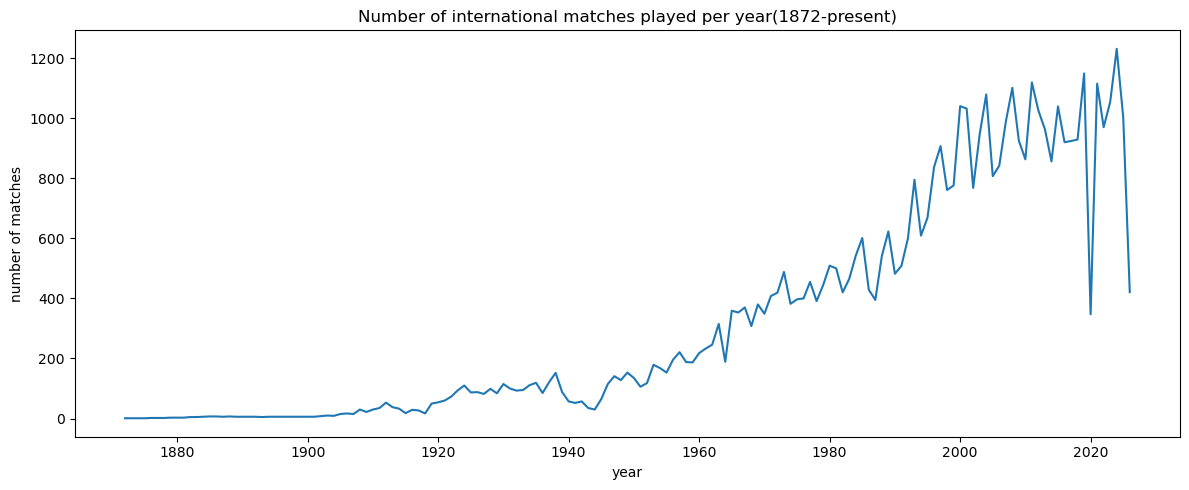

In [99]:
matches_per_year = results.groupby("year").size()

plt.figure(figsize=(12,5))
matches_per_year.plot(kind = "line" , color = "#1f77b4")
plt.title("Number of international matches played per year(1872-present)")
plt.xlabel("year")
plt.ylabel("number of matches")
plt.tight_layout()
plt.show()

# 8 . Distibution of total goals per match

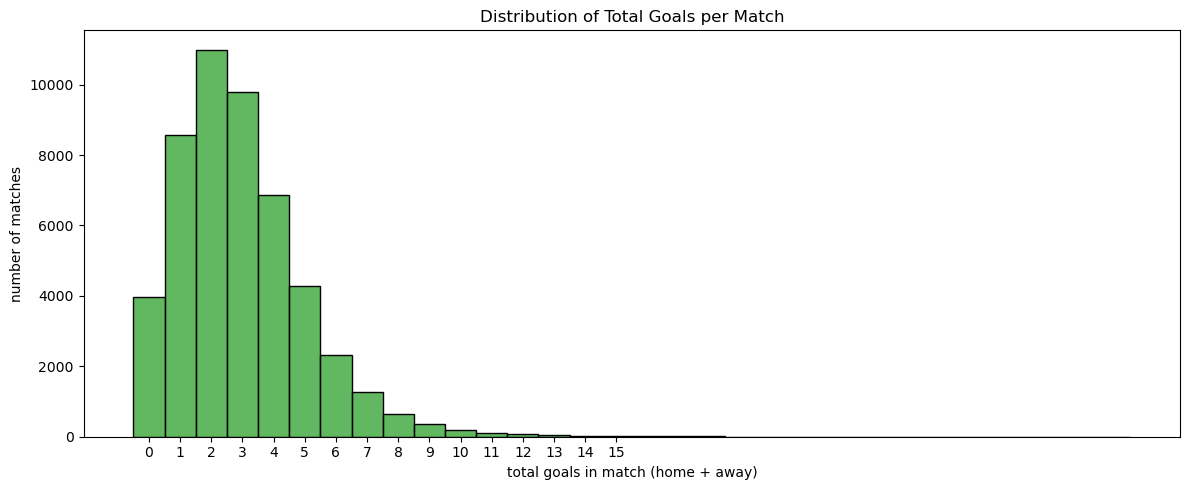

In [100]:
plt.figure(figsize=(12,5))
sns.histplot(results["total_goals"], bins = range(0,16) , discrete = True , color = "#2ca02c")
plt.title("Distribution of Total Goals per Match")
plt.xlabel("total goals in match (home + away)")
plt.ylabel("number of matches")
plt.xticks(range(0,16))
plt.tight_layout()
plt.show()

# 9 . Match outcomes : does home advantage exist?

We count how often matches end in a Home Win, Away Win, or Draw. A higher share of home wins is the classic signature of home advantage' in football.

outcome
Home Win    24264
Away Win    13996
Draw        11258
Name: count, dtype: int64

outcome
Home Win    49.0%
Away Win    28.3%
Draw        22.7%
Name: count, dtype: object


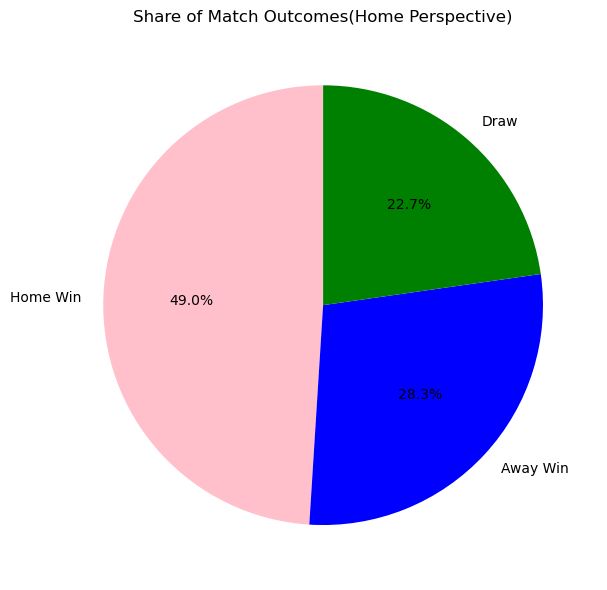

In [101]:
outcome_counts = results['outcome'].value_counts()
outcome_pct = (outcome_counts/outcome_counts.sum()*100).round(1)

print(outcome_counts)
print()
print(outcome_pct.astype(str)+"%")

plt.figure(figsize=(7,6))
color = ["Pink","blue","green"]
plt.pie(outcome_counts,labels=outcome_counts.index,autopct="%1.1f%%",colors=color, startangle=90)
plt.title("Share of Match Outcomes(Home Perspective)")
plt.tight_layout()
plt.show()

# 10 . 10. Which tournaments have the most matches?

We look at the top 10 tournament types by number of matches recorded
(e.g. Friendlies, World Cup qualifiers, continental championships).


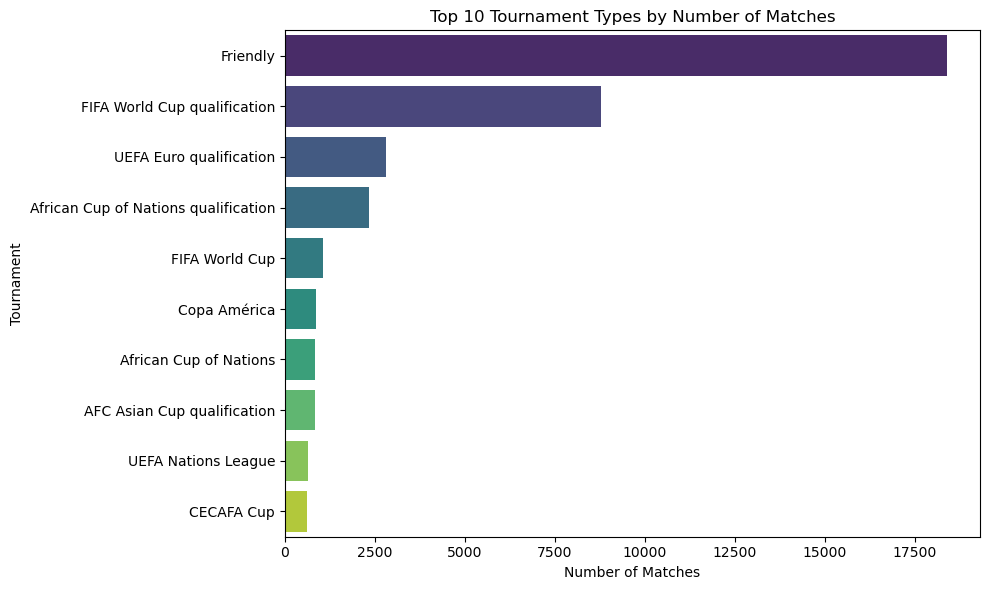

In [102]:
top_tournaments = results["tournament"].value_counts().head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_tournaments.values,
    y=top_tournaments.index,
    hue=top_tournaments.index,
    palette="viridis",
    legend=False
)

plt.title("Top 10 Tournament Types by Number of Matches")
plt.xlabel("Number of Matches")
plt.ylabel("Tournament")
plt.tight_layout()
plt.show()

# 11. Which teams have scored the most goals overall?

To get each team's total goals, we need to combine their goals scored as the home team and as the away team. We do this by grouping twice and addling the results together.

In [103]:
home_goals = results.groupby("home_team")["home_score"].sum()


In [104]:
away_goals = results.groupby("away_team")["away_score"].sum()
away_goals

away_team
Abkhazia          12.0
Afghanistan       86.0
Albania          138.0
Alderney          53.0
Algeria          281.0
                 ...  
Yugoslavia       503.0
Zambia           608.0
Zanzibar         124.0
Zimbabwe         334.0
Åland Islands     27.0
Name: away_score, Length: 322, dtype: float64

In [105]:
# combine both 
total_goals_by_team = home_goals.add(away_goals , fill_value = 0).sort_values(ascending = False )
total_goals_by_team

England      2395.0
Germany      2331.0
Brazil       2315.0
Sweden       2178.0
Argentina    2047.0
              ...  
Manchukuo       0.0
Ryūkyū          0.0
Sark            0.0
Cilento         0.0
Niue            0.0
Length: 337, dtype: float64

In [106]:
top_scoring_teams =  total_goals_by_team.head(10)
top_scoring_teams

England        2395.0
Germany        2331.0
Brazil         2315.0
Sweden         2178.0
Argentina      2047.0
Hungary        2011.0
Netherlands    1852.0
South Korea    1794.0
Mexico         1777.0
France         1731.0
dtype: float64

C:\Users\daffe\AppData\Local\Temp\ipykernel_3984\608332437.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = top_scoring_teams.values , y = top_scoring_teams.index , palette = "rocket")


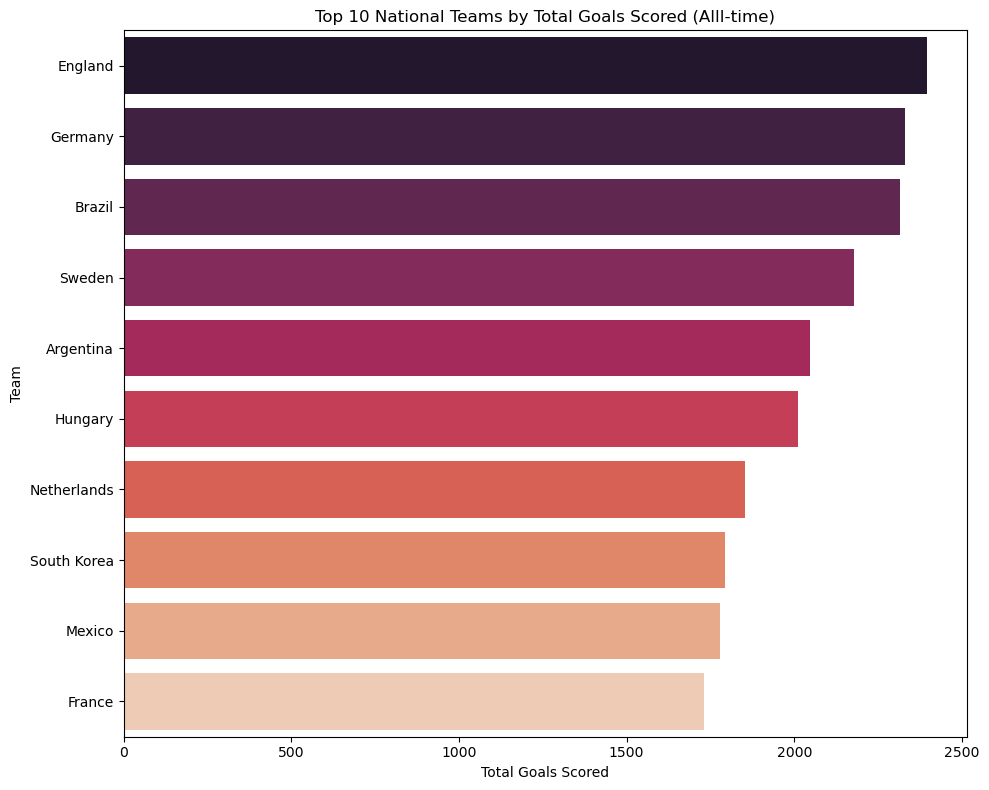

In [107]:
plt.figure(figsize = (10,8))
sns.barplot(x = top_scoring_teams.values , y = top_scoring_teams.index , palette = "rocket")
plt.title("Top 10 National Teams by Total Goals Scored (Alll-time)")
plt.xlabel("Total Goals Scored")
plt.ylabel("Team")
plt.tight_layout()

plt.show()

# 12 . Top individual goalscorers
using the `goalscorers` dataset , we count how many goals each player has scored (across all recorded international matches )  and plot the top 10.

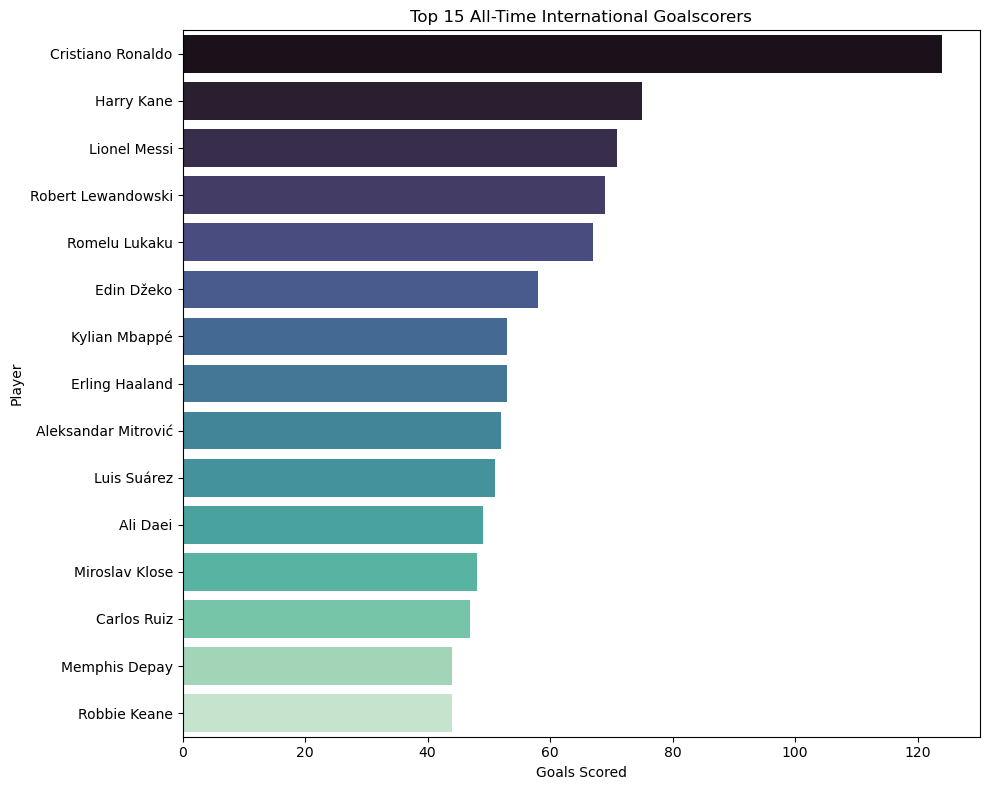

In [108]:
top_scorers = goalscorers["scorer"].value_counts().head(15)

plt.figure(figsize=(10, 8))
sns.barplot(x=top_scorers.values, y=top_scorers.index, hue=top_scorers.index,
            palette="mako", legend=False)
plt.title("Top 15 All-Time International Goalscorers")
plt.xlabel("Goals Scored")
plt.ylabel("Player")
plt.tight_layout()
plt.show()

# 13 . when during a match do goals typically happen ?
we plot a histogram of the `minute` coli=umn from `goalscorers` to see whether goals cluster at certain points in a maych

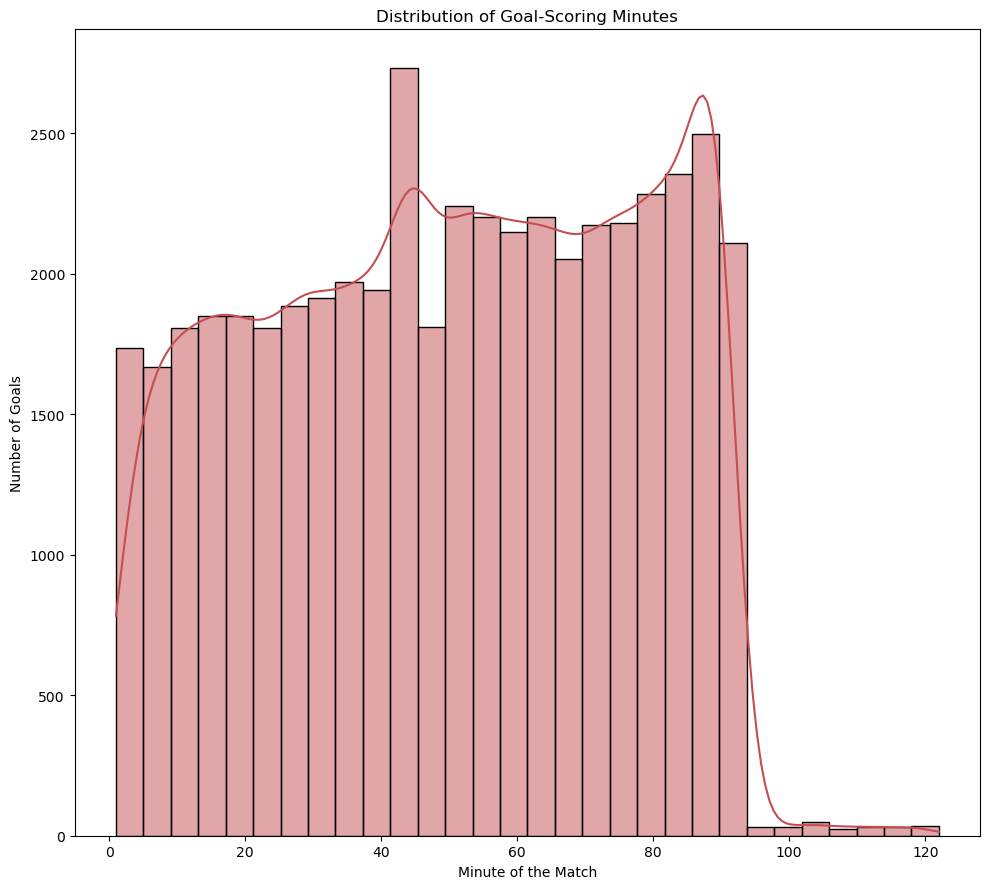

In [109]:
plt.figure(figsize=(10,9))
sns.histplot(goalscorers["minute"].dropna(),bins = 30, color = "#c44e52", kde = True)
plt.title("Distribution of Goal-Scoring Minutes")
plt.xlabel("Minute of the Match")
plt.ylabel("Number of Goals")
plt.tight_layout()
plt.show()

# 14 . penalty Vs open-play vs own goals
the `penalty` and `own_goal` boolean columns let us break down how goals are scored

In [110]:
def goal_type(row):
          if row["penalty"]:
              return "Penalty"
          elif row["own_goal"]:
              return "Own Goal"
          else:
              return "Open Play"

goalscorers["goal_type"] = goalscorers.apply(goal_type, axis=1)
goal_type_counts = goalscorers["goal_type"].value_counts()
goalscorers

,date,home_team,away_team,team,scorer,minute,own_goal,penalty,year,goal_type
0,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,44.0,False,False,1916,Open Play
1,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,55.0,False,False,1916,Open Play
2,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,70.0,False,False,1916,Open Play
3,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,75.0,False,False,1916,Open Play
4,1916-07-06,Argentina,Chile,Argentina,Alberto Ohaco,2.0,False,False,1916,Open Play
...,...,...,...,...,...,...,...,...,...,...
47898,2026-07-14,France,Spain,Spain,Mikel Oyarzabal,22.0,False,True,2026,Penalty
47899,2026-07-14,France,Spain,Spain,Pedro Porro,58.0,False,False,2026,Open Play
47900,2026-07-15,England,Argentina,England,Anthony Gordon,55.0,False,False,2026,Open Play
47901,2026-07-15,England,Argentina,Argentina,Enzo Fernández,85.0,False,False,2026,Open Play


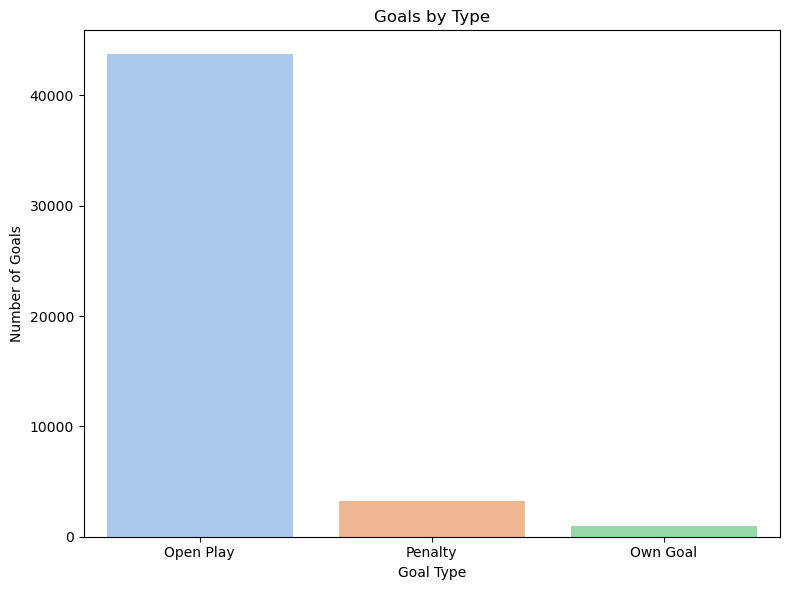

goal_type
Open Play    43702
Penalty       3265
Own Goal       936
Name: count, dtype: int64

In [111]:
#Goals by Type#
plt.figure(figsize=(8, 6))
sns.barplot(x=goal_type_counts.index, y=goal_type_counts.values, hue=goal_type_counts.index,
            palette="pastel", legend=False)
plt.title("Goals by Type")
plt.ylabel("Number of Goals")
plt.xlabel("Goal Type")
plt.tight_layout()
plt.show()

goal_type_counts

# 15. Penalty shootouts: who wins more often?

Shootouts are a coin-flip in theory. Let's check whether the home team wins shootouts more often than the away team in this dataset.: # A shootout's 'winner' is a team name -- we compare it to home_team/away_team to classify it

In [112]:
 shootouts["winner_side"] = np.where(shootouts["winner"] == shootouts["home_team"], "Home Team Won",
           np.where(shootouts["winner"] == shootouts["away_team"], "Away Team Won", "Other"))

shootout_side_counts = shootouts["winner_side"].value_counts()
print(shootout_side_counts)

winner_side
Home Team Won    368
Away Team Won    315
Name: count, dtype: int64


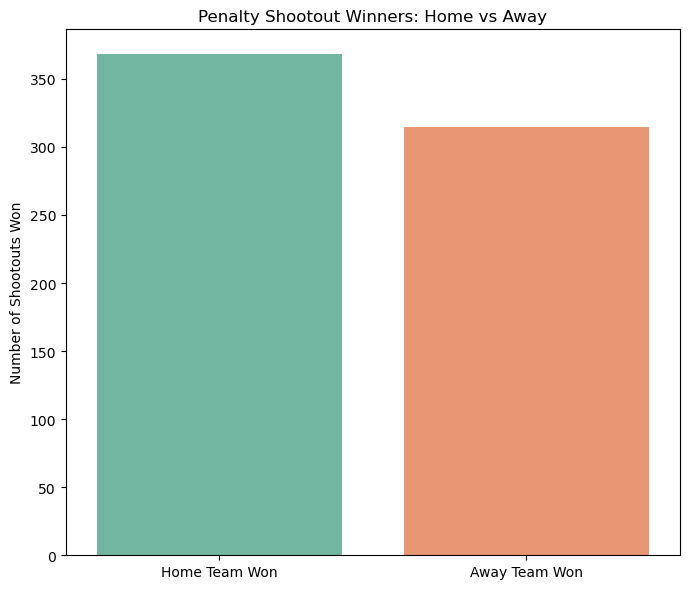

In [113]:
plt.figure(figsize=(7, 6))
sns.barplot(x=shootout_side_counts.index, y=shootout_side_counts.values,
                   hue=shootout_side_counts.index, palette="Set2", legend=False)
plt.title("Penalty Shootout Winners: Home vs Away")
plt.ylabel("Number of Shootouts Won")
plt.xlabel("")
plt.tight_layout()
plt.show()

# 16. Goals per year: is scoring trending up or down?
We compute the average total goals per match for each year, then plot the trend line to see whether football has become higher- or lower-scoring over time.

In [114]:
results["date"] = pd.to_datetime(results["date"])
results["year"] = results["date"].dt.year

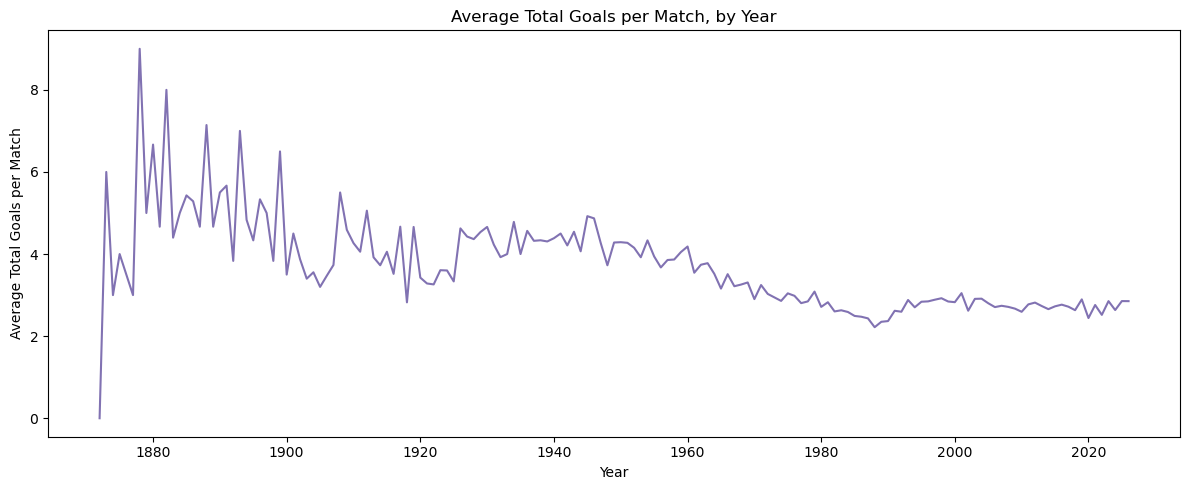

In [116]:
avg_goals_per_year = results.groupby("year")["total_goals"].mean()

plt.figure(figsize=(12, 5))
avg_goals_per_year.plot(color="#8172b2")
plt.title("Average Total Goals per Match, by Year")
plt.xlabel("Year")
plt.ylabel("Average Total Goals per Match")
plt.tight_layout()
plt.show()

# 17. Correlation Heatmap of Numeric Features
A quick heatmap of correlations between our numeric columns ( home_score , away_score , total_goals , goal_diff ). This is a standard EDA step to spot any strong linear relationships between variables

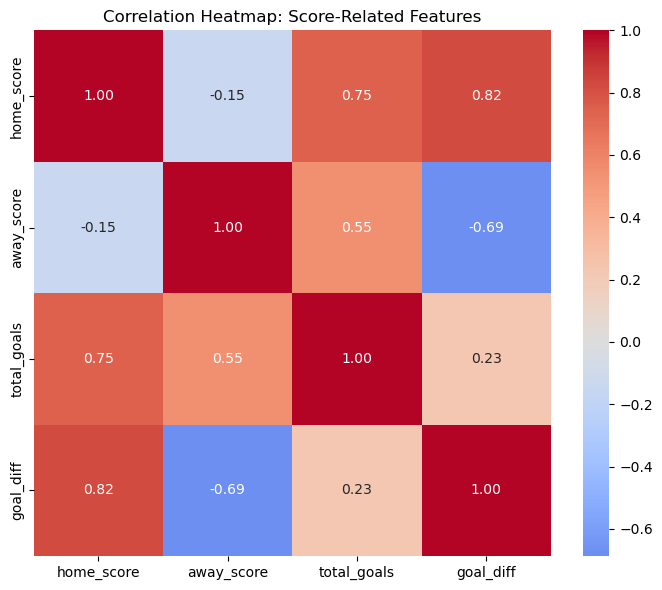

In [117]:
numeric_cols = results[["home_score", "away_score", "total_goals", "goal_diff"]]      
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Heatmap: Score-Related Features")
plt.tight_layout()
plt.show()

# 18 . Former  team  names -- a quick look
This small reference dataset records historical name changes for national teams(e.g. countries that were renamed adter independence or political change).

In [118]:
# How many years was each former name in use?

former_names["years_in_use"] = ((former_names["end_date"] - former_names["start_date"]).dt.days / 365.25).round(1)

former_names.sort_values("years_in_use", ascending=False)[
    ["current", "former", "start_date", "end_date", "years_in_use"]
]

,current,former,start_date,end_date,years_in_use
22,Northern Ireland,Ireland,1882-02-18,1956-04-11,74.1
25,Russia,Soviet Union,1924-11-16,1991-11-13,67.0
15,Guyana,British Guiana,1905-07-21,1967-08-02,62.0
31,Suriname,Dutch Guyana,1921-01-28,1975-11-25,54.8
2,Curaçao,Netherlands Antilles,1957-03-03,2010-10-10,53.6
12,Eswatini,Swaziland,1968-05-01,2018-04-19,50.0
20,Myanmar,Burma,1952-03-14,1989-01-01,36.8
35,Zimbabwe,Southern Rhodesia,1946-06-16,1980-04-18,33.8
10,Djibouti,French Somaliland,1947-12-05,1977-06-27,29.6
33,Vanuatu,New Hebrides,1951-10-04,1980-07-30,28.8
